In [1]:
!pip install numpy matplotlib seaborn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [3]:
SIZE = 30        # 30x30-as rács
P_ALIVE = 0.5    # kezdetben 50% eséllyel élő sejt
INTERVAL = 400   # frissítés ezredmásodpercben

In [4]:
grid = np.random.choice([0, 1], size=(SIZE, SIZE), p=[1-P_ALIVE, P_ALIVE])

In [5]:
def next_generation(grid):
    new_grid = grid.copy()

    for i in range(1, SIZE - 1):
        for j in range(1, SIZE - 1):
            neighbors = np.sum(grid[i-1:i+2, j-1:j+2]) - grid[i, j]

            if neighbors < 2:
                new_grid[i, j] = 0
            elif neighbors == 3:
                new_grid[i, j] = 1
            elif neighbors > 3:
                new_grid[i, j] = 0
            # ha neighbors == 2, marad változatlan

    return new_grid

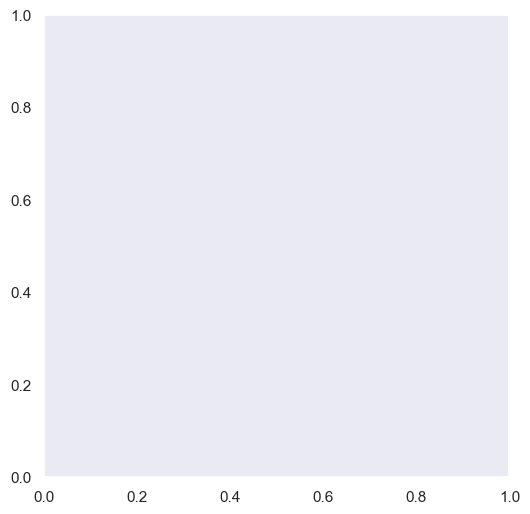

In [9]:
sns.set_theme(style="dark")

fig, ax = plt.subplots(figsize=(6, 6))

In [7]:
def update(frame):
    global grid
    grid = next_generation(grid)

    ax.clear()
    sns.heatmap(
        grid,
        cmap=["black", "white"],
        cbar=False,
        square=True,
        linewidths=0.2,
        linecolor="gray",
        xticklabels=False,
        yticklabels=False,
        ax=ax
    )
    ax.set_title(f"Conway's Game of Life – Generation {frame}")

In [8]:
ani = FuncAnimation(fig, update, frames=200, interval=INTERVAL)
HTML(ani.to_jshtml())